# Лаб.6 Ульченко 24ВВИм1

### Задание: выделить перец

(np.float64(-0.5), np.float64(767.5), np.float64(511.5), np.float64(-0.5))

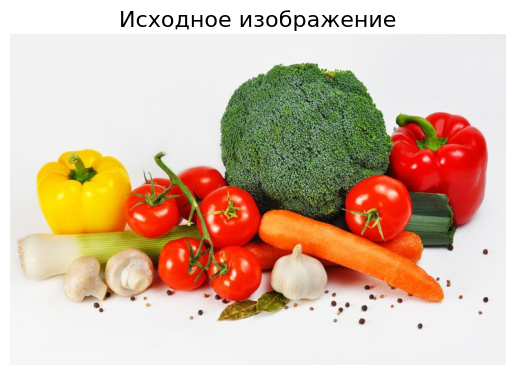

In [104]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.imshow(cv.cvtColor(cv2.imread('vegetables.jpg'), cv2.COLOR_BGR2RGB))
plt.title('Исходное изображение', fontsize=16)
plt.axis('off')

C:\Users\ulche\AppData\Local\Temp\ipykernel_5276\1811877749.py:39: RuntimeWarning: overflow encountered in scalar add
  similarity = sum(abs(image[x, y, :] - image[seed_x, seed_y, :]))/3


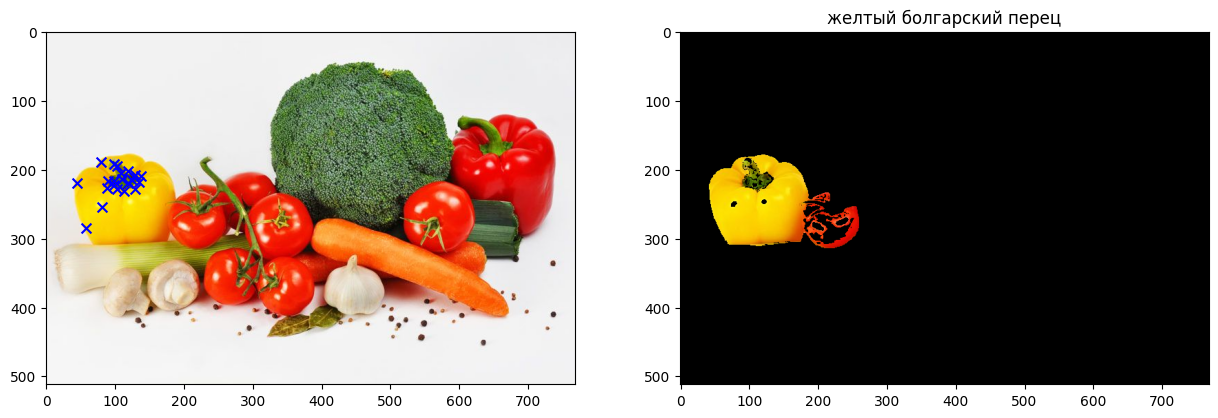

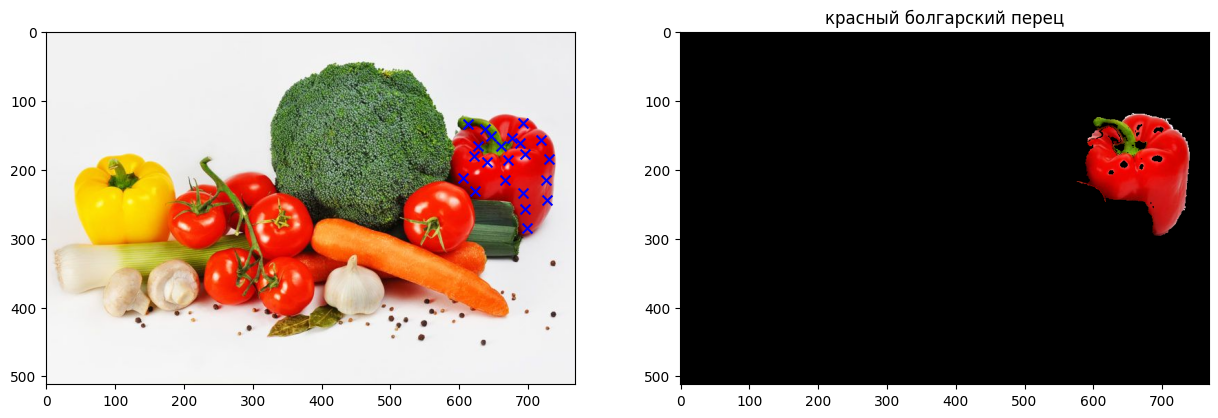

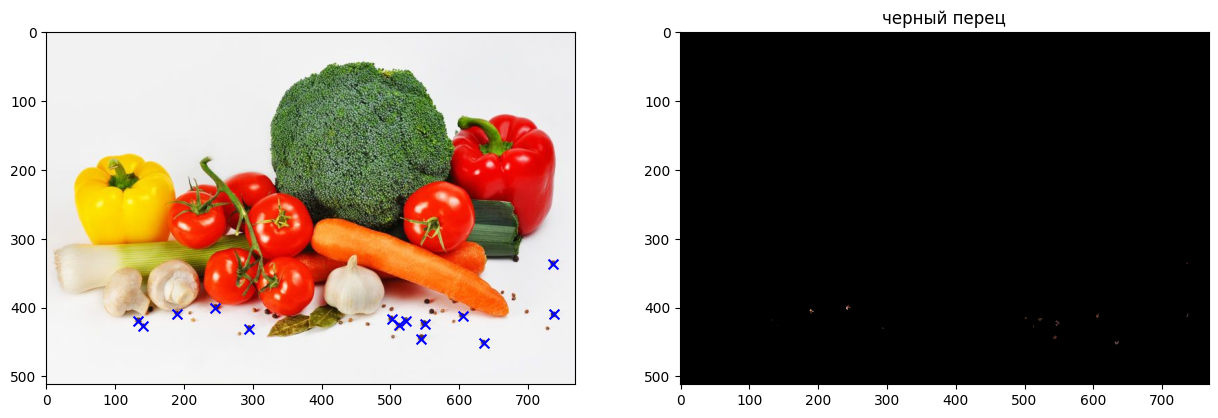

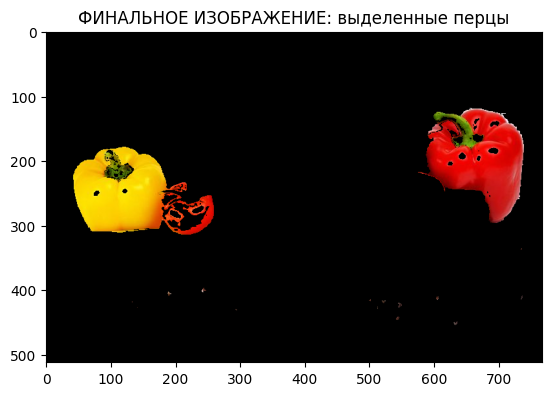

In [107]:
image = cv.imread('vegetables.jpg')
image_hsv = cv.cvtColor(image, cv.COLOR_RGB2HSV)
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

def pick_seeds_interactive(image_bgr, window_name='Image - Кликните для выбора seeds (ESC для выхода)'):
    seeds_collected = []
    def mouse_callback(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            #print(f"Добавлена seed-точка: ({y}, {x})  # row, col") # пока не нужно, оставил для отладки
            seeds_collected.append((y, x))
            cv.circle(display_image, (x, y), 3, (0, 255, 0), -1)
            cv.imshow(window_name, display_image)
    display_image = image_bgr.copy()
    cv.namedWindow(window_name, cv.WINDOW_NORMAL)
    cv.resizeWindow(window_name, 1200, 800) 
    cv.setMouseCallback(window_name, mouse_callback)
    while True:
        cv.imshow(window_name, display_image)
        key = cv.waitKey(1) & 0xFF
        if key == 27: 
            break
    cv.destroyWindow(window_name)
    #print(f"Сбор завершён. Собранные seeds: {seeds_collected}") # пока не нужно, оставил для отладки
    return seeds_collected

def region_growingHSV(image, seed, threshold):
    region_mask = np.zeros(image.shape[0:2], dtype=np.uint8)
    connectivity = [(1, 0), (-1, 0), (0, 1), (0, -1)]
    queue = []
    for i in seed:
        seed_x, seed_y = i
        queue.append((seed_x, seed_y))
        while len(queue) > 0:
            x, y = queue.pop(0)
            if x < 0 or x >= image.shape[0] or y < 0 or y >= image.shape[1]:
                continue
            if region_mask[x, y] != 0:
                continue
            similarity = sum(abs(image[x, y, :] - image[seed_x, seed_y, :]))/3
            if similarity < threshold:
                region_mask[x, y] = 255 
                for dx, dy in connectivity:
                    queue.append((x + dx, y + dy))
    return region_mask



# seeds_yellow = pick_seeds_interactive(image)
# верхняя строчка для задания seeds через диалоговое окно (не работает в colab)
# нижняя строчка - альтернатива, если лень прокликивать или нет возможности
# ненужную комментим, нужную раскомменчиваем
seeds_yellow = [(216, 90), (226, 88), (228, 102), (231, 112), (227, 129), (218, 135), (209, 138), (207, 129), (202, 119), (216, 98), (222, 98), (219, 118), (215, 125), (213, 110), (204, 109), (194, 103), (191, 98), (189, 79), (219, 45), (285, 57), (254, 81)]

threshold_yellow = 22
x_yellow = list(map(lambda x_yellow: x_yellow[1], seeds_yellow))
y_yellow = list(map(lambda x_yellow: x_yellow[0], seeds_yellow))
segmented_region_yellow = region_growingHSV(image_hsv, seeds_yellow, threshold_yellow)
result_yellow = cv.bitwise_and(image, image, mask=segmented_region_yellow)
plt.figure(figsize=(15,20))
plt.subplot(1, 2, 1)
plt.scatter(x_yellow, y_yellow, marker="x", color="blue", s=50)
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.title('желтый болгарский перец')
plt.imshow(cv.cvtColor(result_yellow, cv.COLOR_BGR2RGB))
plt.show()


#seeds_red = pick_seeds_interactive(image)
# верхняя строчка для задания seeds через диалоговое окно (не работает в colab)
# нижняя строчка - альтернатива, если лень прокликивать или нет возможности
# ненужную комментим, нужную раскомменчиваем
seeds_red = [(165, 627), (179, 622), (188, 640), (186, 671), (177, 695), (161, 689), (154, 677), (165, 660), (150, 646), (140, 638), (133, 613), (284, 698), (257, 696), (234, 693), (215, 667), (212, 606), (230, 623), (243, 728), (214, 726), (184, 730), (157, 719), (132, 692)]

threshold_red = 32
x_red = list(map(lambda x_red: x_red[1], seeds_red))
y_red = list(map(lambda x_red: x_red[0], seeds_red))
segmented_region_red = region_growingHSV(image_hsv, seeds_red, threshold_red)
result_red = cv.bitwise_and(image, image, mask=segmented_region_red)
plt.figure(figsize=(15,20))
plt.subplot(1, 2, 1)
plt.scatter(x_red, y_red, marker="x", color="blue", s=50)
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.title('красный болгарский перец')
plt.imshow(cv.cvtColor(result_red, cv.COLOR_BGR2RGB))
plt.show()



# seeds_black = pick_seeds_interactive(image)
# верхняя строчка для задания seeds через диалоговое окно (не работает в colab)
# нижняя строчка - альтернатива, если лень прокликивать или нет возможности
# ненужную комментим, нужную раскомменчиваем
seeds_black = [(419, 133), (427, 141), (409, 190), (401, 245), (431, 294), (417, 502), (426, 513), (420, 522), (424, 550), (445, 545), (412, 605), (452, 636), (410, 737), (336, 736)]

threshold_black = 8
x_black = list(map(lambda x_black: x_black[1], seeds_black))
y_black = list(map(lambda x_black: x_black[0], seeds_black))
segmented_region_black = region_growingHSV(image_hsv, seeds_black, threshold_black)
result_black = cv.bitwise_and(image, image, mask=segmented_region_black)
plt.figure(figsize=(15,20))
plt.subplot(1, 2, 1)
plt.scatter(x_black, y_black, marker="x", color="blue", s=50)
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.title('черный перец')
plt.imshow(cv.cvtColor(result_black, cv.COLOR_BGR2RGB))
plt.show()

combined_mask = cv.bitwise_or(segmented_region_yellow, segmented_region_red)
combined_mask = cv.bitwise_or(combined_mask, segmented_region_black)
final = cv.bitwise_and(image, image, mask=combined_mask)
plt.title('ФИНАЛЬНОЕ ИЗОБРАЖЕНИЕ: выделенные перцы')
plt.imshow(cv.cvtColor(final, cv.COLOR_BGR2RGB))
plt.show()